# 基金数据探索 Notebook

> **用途**：交互式探索数据库中的基金净值数据，验证因子计算逻辑，为 Phase 3 回测引擎做准备。
> **运行环境**：项目虚拟环境（`../.venv/bin/python`）
> **数据路径**：`../data/fund_data.db`

---

In [1]:
import sqlite3
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# 让 matplotlib 图表直接显示在 cell 下方
%matplotlib inline

# 把项目源码目录加入 Python 路径，这样就能直接 import 项目模块
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

# 项目核心模块
from fund_screener.storage import DataStore
from fund_screener.screener import calculate_ma, calculate_trend_stats
from fund_screener.risk_metrics import momentum_score, max_drawdown, sharpe_ratio

# 数据库路径
DB_PATH = PROJECT_ROOT / "data" / "fund_data.db"

print(f"项目根目录: {PROJECT_ROOT}")
print(f"数据库路径: {DB_PATH}")
print(f"数据库存在: {DB_PATH.exists()}")

项目根目录: /Users/mrlonely/mrlonely/mrlonely-code/gitclone/analyze
数据库路径: /Users/mrlonely/mrlonely/mrlonely-code/gitclone/analyze/data/fund_data.db
数据库存在: True


---
## Cell 1: 数据全景 — 数据库里有什么

In [4]:
conn = sqlite3.connect(str(DB_PATH))

# 各表数据量
tables = ["funds", "nav_records", "screening_results", "holdings", "sector_exposure"]
for t in tables:
    cnt = conn.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
    print(f"{t:20s}: {cnt:,} 条")

# 按市场分布
print("\n--- 按市场分布 ---")
df_market = pd.read_sql_query("SELECT market, COUNT(*) as cnt FROM funds GROUP BY market", conn)
display(df_market)

# 最新筛选日期
latest_screen = conn.execute("SELECT MAX(screening_date) FROM screening_results").fetchone()[0]
print(f"\n最新筛选日期: {latest_screen}")

conn.close()

funds               : 766 条
nav_records         : 75,644 条
screening_results   : 1,146 条
holdings            : 95 条
sector_exposure     : 3,158 条

--- 按市场分布 ---


,market,cnt
0,CN,527
1,HK,154
2,US,85



最新筛选日期: 2026-03-21


---
## Cell 2: 单只基金深度分析 — 任选一只看净值走势

In [5]:
# 先列出所有基金，你挑一只改下面的 CODE
conn = sqlite3.connect(str(DB_PATH))
df_funds = pd.read_sql_query("SELECT code, name, market FROM funds ORDER BY code LIMIT 10", conn)
display(df_funds)
conn.close()

,code,name,market
0,000017,财通可持续混合,CN
1,000354,长盛城镇化主题混合A,CN
2,000390,华商优势行业混合A,CN
3,000404,易方达新兴成长灵活配置,CN
4,000411,景顺长城优质成长股票A,CN
5,000522,华润元大信息传媒科技混合A,CN
6,000531,东吴阿尔法灵活配置混合A,CN
7,000603,易方达创新驱动灵活配置混合,CN
8,000697,汇添富移动互联股票A,CN
9,000698,宝盈科技30混合,CN


In [6]:
# ========== 改成你想看的基金代码 ==========
FUND_CODE = "000531"   # 改这里，比如 "510300" (沪深300ETF)、"SPY" 等
MARKET = "CN"          # CN / US / HK
# ==========================================

conn = sqlite3.connect(str(DB_PATH))

# 拉取净值历史
sql = """
SELECT n.date, n.nav, COALESCE(n.adj_nav, n.nav) as adj_nav
FROM nav_records n
JOIN funds f ON n.fund_id = f.id
WHERE f.code = ? AND f.market = ?
ORDER BY n.date
"""
df_nav = pd.read_sql_query(sql, conn, params=(FUND_CODE, MARKET))
df_nav["date"] = pd.to_datetime(df_nav["date"])
df_nav = df_nav.set_index("date")

# 基金名称
fund_name = conn.execute(
    "SELECT name FROM funds WHERE code = ? AND market = ?", (FUND_CODE, MARKET)
).fetchone()[0]

conn.close()

print(f"基金: {fund_name} ({FUND_CODE})")
print(f"数据条数: {len(df_nav)}")
print(f"日期范围: {df_nav.index.min().date()} ~ {df_nav.index.max().date()}")
display(df_nav.tail())

基金: 东吴阿尔法灵活配置混合A (000531)
数据条数: 100
日期范围: 2025-10-22 ~ 2026-03-20


,nav,adj_nav
date,,
2026-03-16,2.3404,2.3404
2026-03-17,2.2758,2.2758
2026-03-18,2.3502,2.3502
2026-03-19,2.3086,2.3086
2026-03-20,2.3287,2.3287


---
## Cell 3: MA 均线可视化 — 多头排列/空头排列一眼看清

/var/folders/l1/jwdhccrx4rl4sqsjq2m5l3c40000gp/T/ipykernel_9406/4127746351.py:23: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l1/jwdhccrx4rl4sqsjq2m5l3c40000gp/T/ipykernel_9406/4127746351.py:23: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l1/jwdhccrx4rl4sqsjq2m5l3c40000gp/T/ipykernel_9406/4127746351.py:23: UserWarning: Glyph 20928 (\N{CJK UNIFIED IDEOGRAPH-51C0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l1/jwdhccrx4rl4sqsjq2m5l3c40000gp/T/ipykernel_9406/4127746351.py:23: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l1/jwdhccrx4rl4sqsjq2m5l3c40000gp/T/ipykernel_9406/4127746351.py:23: UserWarning: Glyph 19996 (\N{CJK UNIFIED IDEOGRAPH-4E1C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/l1/jwdhccrx4

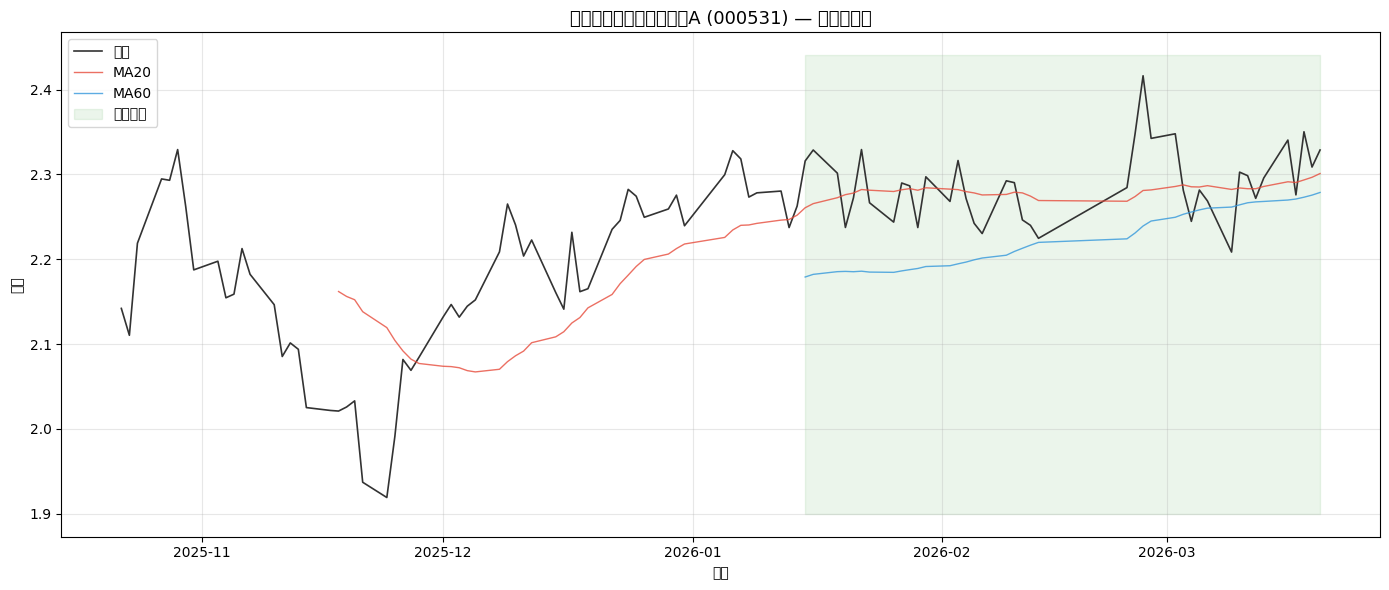


当前状态: 多头排列 ✅
MA20=2.3010, MA60=2.2786, 差值=0.98%


In [7]:
# 计算 MA
df_nav["MA20"] = calculate_ma(df_nav["adj_nav"], 20)
df_nav["MA60"] = calculate_ma(df_nav["adj_nav"], 60)

# 只看最近 120 个交易日（画图清楚点）
df_plot = df_nav.tail(120)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_plot.index, df_plot["adj_nav"], label="净值", linewidth=1.2, color="#333")
ax.plot(df_plot.index, df_plot["MA20"], label="MA20", linewidth=1, color="#e74c3c", alpha=0.8)
ax.plot(df_plot.index, df_plot["MA60"], label="MA60", linewidth=1, color="#3498db", alpha=0.8)

# 多头排列区域（MA20 > MA60）标绿
bull_mask = df_plot["MA20"] > df_plot["MA60"]
ax.fill_between(df_plot.index, df_plot["adj_nav"].min()*0.99, df_plot["adj_nav"].max()*1.01,
                where=bull_mask, alpha=0.08, color="green", label="多头排列")

ax.set_title(f"{fund_name} ({FUND_CODE}) — 净值与均线", fontsize=13)
ax.set_xlabel("日期")
ax.set_ylabel("净值")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 当前状态
latest = df_nav.iloc[-1]
is_bull = latest["MA20"] > latest["MA60"]
diff_pct = (latest["MA20"] - latest["MA60"]) / latest["MA60"] * 100
print(f"\n当前状态: {'多头排列 ✅' if is_bull else '空头排列 ❌'}")
print(f"MA20={latest['MA20']:.4f}, MA60={latest['MA60']:.4f}, 差值={diff_pct:.2f}%")

---
## Cell 4: 三因子风险指标 — 给这只基金做"体检"

In [ ]:
# 用 adj_nav 序列计算三因子
nav_series = df_nav["adj_nav"].dropna()

m = momentum_score(nav_series)
d = max_drawdown(nav_series)
s = sharpe_ratio(nav_series)

print(f"""
{'='*40}
  三因子体检报告 — {fund_name}
{'='*40}
趋势爆发力 (momentum):  {m:>+10.4f}  {'↑ 强势' if m > 0 else '↓ 弱势'}
最大回撤   (drawdown):  {d:>10.2%}  {'（历史上最大亏这么多）'}
夏普比率   (sharpe):    {s:>10.4f}  {'↑ 性价比高' if s > 1 else '→ 一般' if s > 0 else '↓ 差'}
数据天数:              {len(nav_series):>10,}  条
{'='*40}
""")

# 多周期涨跌幅
trend = calculate_trend_stats(df_nav.reset_index().rename(columns={"date": "date"}))
print(f"\n多周期涨跌幅:")
for k, v in trend.model_dump().items():
    if v is not None:
        print(f"  {k}: {v:+.2f}%")
    else:
        print(f"  {k}: (数据不足)")

---
## Cell 5: 回撤曲线 — 历史上最惨的时候有多惨

In [ ]:
# 计算回撤序列
nav = nav_series.astype(float)
cummax = nav.cummax()
drawdown = (nav - cummax) / cummax * 100  # 转成百分比

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(drawdown.index, drawdown, 0, alpha=0.3, color="red")
ax.plot(drawdown.index, drawdown, linewidth=0.8, color="#c0392b")
ax.axhline(y=drawdown.min(), color="black", linestyle="--", alpha=0.5,
           label=f"最大回撤: {drawdown.min():.2f}%")
ax.set_title(f"{fund_name} — 历史回撤曲线")
ax.set_ylabel("回撤 %")
ax.set_xlabel("日期")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 最大回撤发生的日期
max_dd_date = drawdown.idxmin()
print(f"\n最大回撤发生在: {max_dd_date.date()}，回撤 {drawdown.min():.2f}%")

---
## Cell 6: 信号矩阵原型 — 为 Phase 3 回测引擎热身

> 回测引擎的核心输入是 `signal_df`：一个 `(date × fund_code)` 的布尔矩阵。
> 这里演示如何把 MA 筛选逻辑变成一个信号矩阵。

In [ ]:
# 选前 5 只基金做演示
conn = sqlite3.connect(str(DB_PATH))
codes = pd.read_sql_query("SELECT code FROM funds WHERE market='CN' LIMIT 5", conn)["code"].tolist()

all_signals = {}

for code in codes:
    sql = """
    SELECT n.date, COALESCE(n.adj_nav, n.nav) as nav
    FROM nav_records n
    JOIN funds f ON n.fund_id = f.id
    WHERE f.code = ? AND f.market = 'CN'
    ORDER BY n.date
    """
    df = pd.read_sql_query(sql, conn, params=(code,))
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date")
    
    if len(df) >= 60:
        df["MA20"] = calculate_ma(df["nav"], 20)
        df["MA60"] = calculate_ma(df["nav"], 60)
        # 信号: MA20 > MA60 → True（多头排列，应持仓）
        signal = (df["MA20"] > df["MA60"]).reindex(df.index)
        all_signals[code] = signal

conn.close()

# 组装成信号矩阵 (date × fund_code)
signal_df = pd.DataFrame(all_signals)
signal_df = signal_df.dropna(how="all")   # 去掉全是 NaN 的行

print(f"信号矩阵形状: {signal_df.shape}")  # (日期数, 基金数)
print(f"\n最近 10 个交易日信号（True=持仓, False=空仓）:")
display(signal_df.tail(10).astype(bool).replace({True: "📈持仓", False: "📉空仓"}))

# 每只基金的持仓天数占比
hold_ratio = signal_df.mean() * 100
print("\n持仓天数占比:")
for code, ratio in hold_ratio.items():
    print(f"  {code}: {ratio:.1f}%")

---
## Cell 7: 下一步 — 把验证过的逻辑搬进 `.py`

当你在这个 notebook 里验证了一套因子逻辑后，按这个流程搬到生产代码：

1. **因子层**：把信号生成逻辑写进 `src/fund_screener/factor.py`（新建）
2. **策略层**：在 `src/fund_screener/strategy.py`（新建）里定义调仓规则
3. **回测层**：`src/fund_screener/backtest.py`（新建）接收 signal_df，输出权益曲线
4. **单元测试**：在 `tests/` 里写测试覆盖核心计算

Notebook 永远是草稿纸，`.py` + `pytest` 才是交付物。